# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [ ]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
# YOUR CODE HERE
print("Current working directory:", os.getcwd())
print("Contents of the current directory:", os.listdir())

# 2. Acquire and load your primary dataset
# YOUR CODE HERE
import pandas as pd
import requests

# 1. Fetch the data
url = 'https://api.worldbank.org/v2/country?format=json&per_page=300'
response = requests.get(url)
data = pd.DataFrame(response.json()[1])

# 2. CLEAN THE NESTED DICTIONARIES
# Extract just the 'value' from each nested dict

def extract_value(nested_dict):
    """Helper function to extract 'value' from nested dictionary"""
    if isinstance(nested_dict, dict) and 'value' in nested_dict:
        return nested_dict['value']
    return None

# Apply to all the messy columns
data['region'] = data['region'].apply(extract_value)
data['income_level'] = data['incomeLevel'].apply(extract_value)
data['lending_type'] = data['lendingType'].apply(extract_value)

# 3. Select only clean columns
data_clean = data[['id', 'iso2Code', 'name', 'region', 'income_level', 
                    'lending_type', 'capitalCity', 'latitude', 'longitude']]

# 4. Remove aggregates (rows with NaN regions - like "Africa Eastern and Southern")
data_clean = data_clean.dropna(subset=['region', 'income_level'])

Current working directory: d:\Github_Repos\datascience-publicpolicy-2026\notebooks\hw\hw_3
Contents of the current directory: ['hw_3.ipynb', 'hw_3_sou.ipynb']
    id iso2Code                         name  \
0  ABW       AW                        Aruba   
1  AFE       ZH  Africa Eastern and Southern   
2  AFG       AF                  Afghanistan   
3  AFR       A9                       Africa   
4  AFW       ZI   Africa Western and Central   

                                              region income_level  \
0                         Latin America & Caribbean   High income   
1                                         Aggregates   Aggregates   
2  Middle East, North Africa, Afghanistan & Pakistan   Low income   
3                                         Aggregates   Aggregates   
4                                         Aggregates   Aggregates   

     lending_type capitalCity latitude longitude  
0  Not classified  Oranjestad  12.5167  -70.0167  
1      Aggregates                  

### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *Write your source here*

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [8]:
# 1. Inspect data structure using pandas methods
# YOUR CODE HERE
print(data_clean.head())
print(data_clean.shape)

    id iso2Code                         name  \
0  ABW       AW                        Aruba   
1  AFE       ZH  Africa Eastern and Southern   
2  AFG       AF                  Afghanistan   
3  AFR       A9                       Africa   
4  AFW       ZI   Africa Western and Central   

                                              region income_level  \
0                         Latin America & Caribbean   High income   
1                                         Aggregates   Aggregates   
2  Middle East, North Africa, Afghanistan & Pakistan   Low income   
3                                         Aggregates   Aggregates   
4                                         Aggregates   Aggregates   

     lending_type capitalCity latitude longitude  
0  Not classified  Oranjestad  12.5167  -70.0167  
1      Aggregates                                 
2             IDA       Kabul  34.5228   69.1761  
3      Aggregates                                 
4      Aggregates                        

In [12]:
# 2. Rename columns and select a clean subset
#  YOUR CODE HERE
data_clean = data.rename(columns={'id': 'country_id', 'name': 'country_name', 'region': 'region_name'})
data_clean.head(2)

,country_id,iso2Code,country_name,region_name,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude,income_level,lending_type
0,ABW,AW,Aruba,Latin America & Caribbean,"{'id': '', 'iso2code': '', 'value': ''}","{'id': 'HIC', 'iso2code': 'XD', 'value': 'High...","{'id': 'LNX', 'iso2code': 'XX', 'value': 'Not ...",Oranjestad,-70.0167,12.5167,High income,Not classified
1,AFE,ZH,Africa Eastern and Southern,Aggregates,"{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,,Aggregates,Aggregates


In [13]:
# 3. Filter row or column filters if necessary
# YOUR CODE HERE
data_clean = data_clean[['country_id', 'country_name', 'region_name']]
data_clean.head(2)

,country_id,country_name,region_name
0,ABW,Aruba,Latin America & Caribbean
1,AFE,Africa Eastern and Southern,Aggregates


In [14]:
# 4. Handle missing values (NaNs) if necessary
# YOUR CODE HERE
data_clean = data_clean.dropna()
print(data_clean.isnull().sum())

country_id      0
country_name    0
region_name     0
dtype: int64


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [15]:
# 1. Load and clean the secondary dataset
# YOUR CODE HERE
gdp_url = 'https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?format=json&per_page=500&date=2022'
gdp_response = requests.get(gdp_url)
gdp_data = pd.DataFrame(gdp_response.json()[1])

gdp_data['gdp_per_capita'] = gdp_data['value'].apply(lambda x: float(x) if x and x != '0' else None)
gdp_data_clean = gdp_data[['countryiso3code', 'gdp_per_capita']].dropna()
gdp_data_clean = gdp_data_clean.rename(columns={'countryiso3code': 'country_id'})

In [16]:
# 2. Merge your datasets on a common key
# YOUR CODE HERE
merged_data = data_clean.merge(gdp_data_clean, on='country_id', how='inner')
print(f"Merged shape: {merged_data.shape}")
print(merged_data.head())

Merged shape: (253, 4)
  country_id                 country_name  \
0        ABW                        Aruba   
1        AFE  Africa Eastern and Southern   
2        AFG                  Afghanistan   
3        AFW   Africa Western and Central   
4        AGO                       Angola   

                                         region_name  gdp_per_capita  
0                         Latin America & Caribbean     30975.998912  
1                                         Aggregates     1679.327622  
2  Middle East, North Africa, Afghanistan & Pakistan      357.261153  
3                                         Aggregates     2138.473153  
4                                Sub-Saharan Africa      3682.113151  


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Write your merge details here*

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [ ]:
# Apply groupby aggregation or implement one of the backup grouping strategies
# YOUR CODE HERE
region_stats = merged_data.groupby('region_name').agg({
    'gdp_per_capita': ['mean', 'median', 'min', 'max', 'count']
}).round(2)

print(region_stats)

                                                  gdp_per_capita            \
                                                            mean    median   
region_name                                                                  
Aggregates                                              11966.67   6848.28   
East Asia & Pacific                                     18273.32   6682.51   
Europe & Central Asia                                   40174.04  25085.78   
Latin America & Caribbean                               16870.15  11405.79   
Middle East, North Africa, Afghanistan & Pakistan       18804.34   4840.75   
North America                                           84842.66  76657.25   
South Asia                                               4214.97   3029.56   
Sub-Saharan Africa                                       2600.55   1341.51   

                                                                              
                                                        min   

- *Extra Credit: Write your economic or policy related interpretation here*

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

In [19]:
le_url = 'https://api.worldbank.org/v2/country/all/indicator/SP.DYN.LE00.IN?format=json&per_page=500&date=2022'
le = pd.DataFrame(requests.get(le_url).json()[1])
le = le[['countryiso3code','value']].dropna().rename(columns={'countryiso3code':'country_id','value':'life_expectancy'})
merged2 = merged_data.merge(le, on='country_id', how='inner')
df = merged2.dropna(subset=['gdp_per_capita','life_expectancy']).copy()

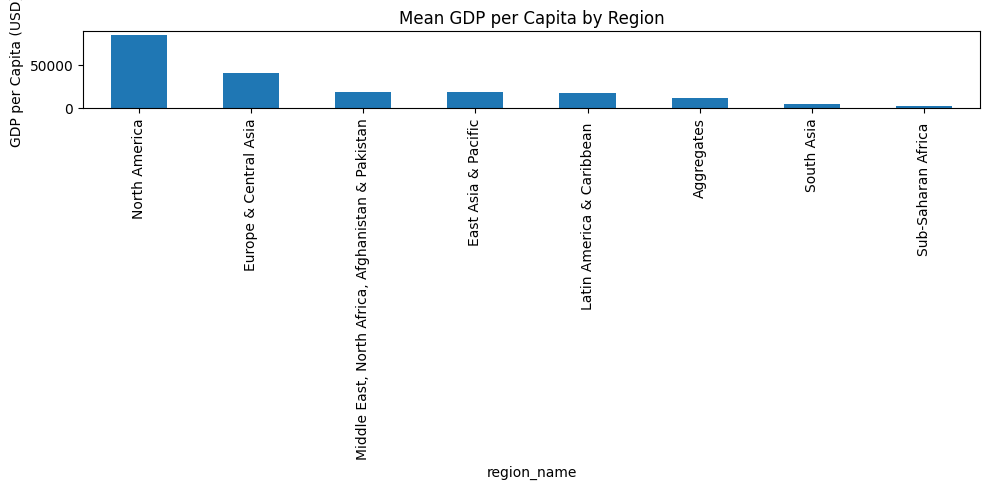

In [20]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
# YOUR CODE HERE
region_mean = df.groupby('region_name')['gdp_per_capita'].mean().sort_values(ascending=False)
ax = region_mean.plot(kind='bar', figsize=(10,5), color='C0', title='Mean GDP per Capita by Region')
ax.set_ylabel('GDP per Capita (USD)')
plt.tight_layout()
plt.show()

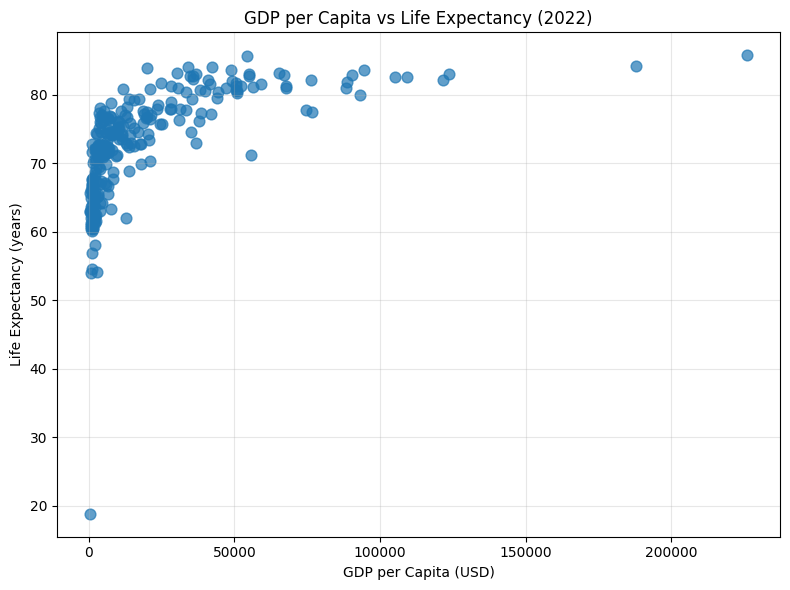

In [21]:
# Plot 2: Customized scatter plot of primary policy variables
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(df['gdp_per_capita'], df['life_expectancy'], alpha=0.7, s=60)
ax.set_xlabel('GDP per Capita (USD)')
ax.set_ylabel('Life Expectancy (years)')
ax.set_title('GDP per Capita vs Life Expectancy (2022)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

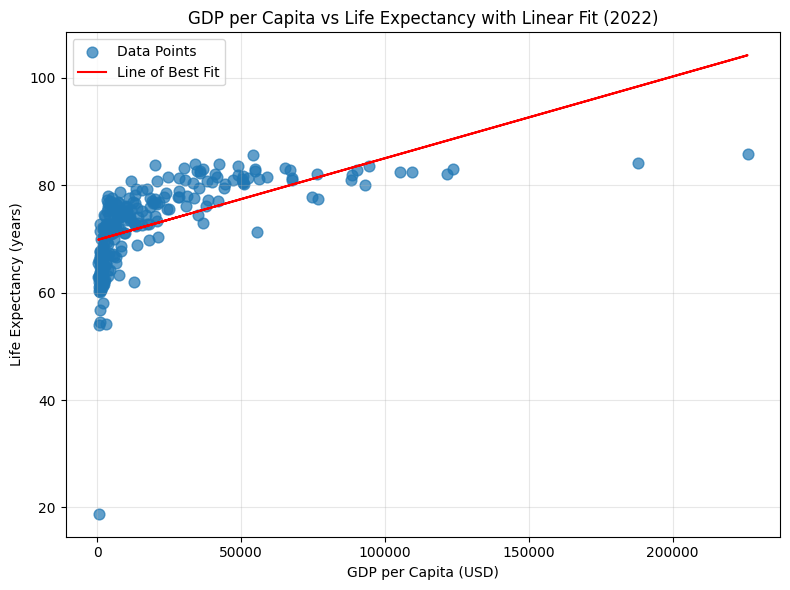

In [23]:
# Fit a simple linear regression and overlay the line of best fit
# YOUR CODE HERE
from sklearn.linear_model import LinearRegression
X = df['gdp_per_capita'].values.reshape(-1, 1)
y = df['life_expectancy'].values
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
plt.figure(figsize=(8,6))
plt.scatter(df['gdp_per_capita'], df['life_expectancy'], alpha=0.7, s=60, label='Data Points')
plt.plot(df['gdp_per_capita'], y_pred, color='red', label='Line of Best Fit')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Life Expectancy (years)')
plt.title('GDP per Capita vs Life Expectancy with Linear Fit (2022)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- *Extra Credit: Write your visualization and regression interpretations here*

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.